In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [29]:
class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.labels = []
        self.class_map = {'no': 0, 'sphere': 1, 'vort': 2}
        self.classes = list(self.class_map.keys())  # Store class names

        for class_name, label in self.class_map.items():
            class_folder = os.path.join(root_dir, class_name)
            if not os.path.exists(class_folder):
                print(f"Warning: {class_folder} not found.")
                continue
            for file in os.listdir(class_folder):
                if file.endswith(".npy"):
                    file_path = os.path.join(class_folder, file)
                    self.data.append(file_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Load .npy file
        image_path = self.data[idx]
        image = np.load(image_path)

        # Ensure image has the correct shape (C, H, W)
        if image.ndim == 2:  # If shape is (H, W), add channel dimension
            image = np.expand_dims(image, axis=0)  # Shape (1, H, W)

        # Convert grayscale (1 channel) to RGB (3 channels)
        if image.shape[0] == 1:
            image = np.repeat(image, 3, axis=0)  # Shape (3, H, W)

        # Convert to PyTorch tensor
        image = torch.tensor(image, dtype=torch.float32)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [30]:
class PINNModel(nn.Module):
    def __init__(self):
        super(PINNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # Pooling to reduce size

        # Use a placeholder for dynamically setting fc1 input size
        self.fc1 = None
        self.fc2 = nn.Linear(256, 3)  # 3 classes

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))  # Reduce size
        x = self.pool(F.relu(self.conv3(x)))  # Reduce size

        # Debugging: Print shape before flattening
        print("Shape before flattening:", x.shape)

        x = x.view(x.size(0), -1)  # Flatten
        feature_size = x.shape[1]  # Get dynamic size

        # Initialize fc1 dynamically
        if self.fc1 is None:
            print(f"Updating fc1 input size to: {feature_size}")
            self.fc1 = nn.Linear(feature_size, 256).to(x.device)  # Match device

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [31]:
def physics_loss(output, target):
    """
    Custom physics-informed loss based on the gravitational lensing equation.
    Encourages the model to predict physically consistent classifications.
    """
    physics_constraint = torch.mean((output[:, 1] - output[:, 2]) ** 2)  # Sample constraint
    classification_loss = F.cross_entropy(output, target)
    return classification_loss + 0.01 * physics_constraint

In [32]:
def train_model(model, train_loader, val_loader, num_epochs=30, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = physics_loss(outputs, labels)  # Use physics-informed loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    return model

In [33]:
def evaluate(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Compute AUC for each class
    auc_scores = []
    for i in range(3):  # 3 classes
        class_labels = (all_labels == i).astype(int)
        class_probs = all_probs[:, i]
        if len(np.unique(class_labels)) > 1:
            auc = roc_auc_score(class_labels, class_probs)
            auc_scores.append(auc)
        else:
            auc_scores.append(float("nan"))  # Avoid error for missing classes

    print(f"Test AUC Scores: {auc_scores}")

    # Plot ROC Curve
    plt.figure(figsize=(6, 6))
    for i in range(3):
        fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

In [34]:
transform = transforms.Compose([
    transforms.ToPILImage(),                  # Convert tensor (from .npy) to PIL image
    transforms.RandomHorizontalFlip(p=0.5),   # 50% chance to flip horizontally
    transforms.RandomRotation(degrees=15),    # Random rotation between -15 and 15 degrees
    transforms.ToTensor(),                    # Convert back to tensor
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))        # Normalize: update the mean and std if needed
])

In [35]:
val_dataset = LensingDataset("/content/drive/MyDrive/dataset/train", transform=transform)
full_dataset = LensingDataset("/content/drive/MyDrive/dataset/val", transform=transform)

In [36]:
# 90:10 split of train data
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

In [37]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [38]:
model = PINNModel()

In [39]:
import torch
torch.cuda.empty_cache()

In [40]:
model = train_model(model, train_loader, val_loader, num_epochs=30, lr=0.001)

Streaming output truncated to the last 5000 lines.
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before f

Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape before flattening: torch.Size([16, 128, 37, 37])
Shape befo

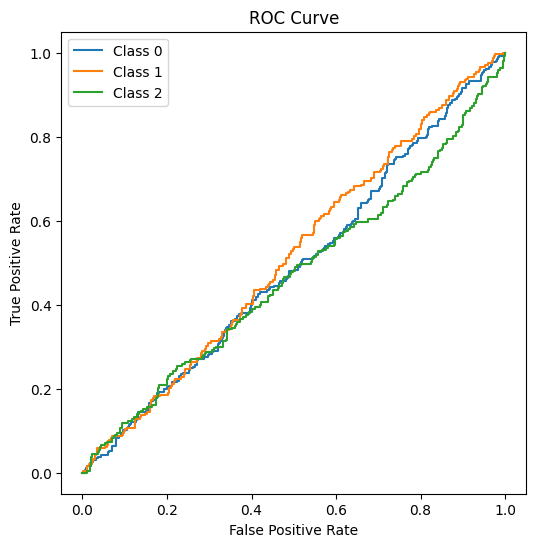

In [41]:
evaluate(model, test_loader)

In [42]:
# Define the path where the model weights will be saved
model_path = "/content/cnn_weights5"

# Save only the model's state_dict (recommended)
torch.save(model.state_dict(), model_path)

print(f"Model weights saved to {model_path}")

Model weights saved to /content/cnn_weights5
